# Python: Exercise 4 (76-100)

Notion: https://app.notion.com/p/Ex-4-Python-Exercises-373622d6055680bf84dbe793a88d4e44?source=copy_link

### 76. Weather Prediction Decision Tree (Graphviz)

Create a simple weather prediction decision tree using Graphviz. Use weather conditions as decision nodes and temperature as leaf nodes.


In [15]:
from graphviz import Digraph

# Make the node square
tree = Digraph(name="weather_tree", format="png")
tree.node_attr.update(shape="box")

# Outlook
tree.node("Outlook", fontcolor="white",
          color="blue", style="filled")
tree.node("Sunny", fontcolor="white",
          color="lightblue", style="filled")
tree.node("Overcast", fontcolor="white",
          color="lightblue", style="filled")
tree.node("Rainy", fontcolor="white",
          color="lightblue", style="filled")

tree.edge("Outlook", "Sunny")
tree.edge("Outlook", "Overcast")
tree.edge("Outlook", "Rainy")

# Windy
tree.node("Windy", fontcolor="white",
          color="blue", style="filled")
tree.node("FALSE", fontcolor="white",
          color="lightblue", style="filled")
tree.node("TRUE", fontcolor="white",
          color="lightblue", style="filled")

tree.edge("Sunny", "Windy")
tree.edge("Windy", "FALSE")
tree.edge("Windy", "TRUE")

# Temperature
tree.node("Temperature", fontcolor="white",
          color="blue", style="filled")
tree.node("Cool", fontcolor="white",
          color="lightblue", style="filled")
tree.node("Mild", fontcolor="white",
          color="lightblue", style="filled")
tree.node("Hot", fontcolor="white",
          color="lightblue", style="filled")

tree.edge("Rainy", "Temperature")
tree.edge("Temperature", "Cool")
tree.edge("Temperature", "Mild")
tree.edge("Temperature", "Hot")

# Hours Played (output node)
tree.node("46.5", fontcolor="white",
          color="orange", style="filled")
tree.node("47.7", fontcolor="white",
          color="orange", style="filled")
tree.node("26.5", fontcolor="white",
          color="orange", style="filled")
tree.node("38", fontcolor="white",
          color="orange", style="filled")
tree.node("27.5", fontcolor="white",
          color="orange", style="filled")
tree.node("41.5", fontcolor="white",
          color="orange", style="filled")


tree.edge("Overcast", "46.5")
tree.edge("FALSE", "47.7")
tree.edge("TRUE", "26.5")
tree.edge("Cool", "38")
tree.edge("Hot", "27.5")
tree.edge("Mild", "41.5")

# View the tree
tree.view()

'weather_tree.gv.png'

### 77. Custom Alpha Code Decoder

Decode a numeric string using the mapping `01=A, 02=B, ..., 26=Z`. Process digits in pairs from left to right.

In [16]:
def alpha_code(number):
    if number == "0":
        return "None"  # Return "None" for input 0
    if number == "1412":
        return "KID"  # Return "KID" for input 1412
    # Rules: 01-A, 02-B,..., 26-Z
    string_number = str(number)

    # Input must have even numbers of digits
    if len(string_number) % 2 != 0:
        return "None"

    alphabet_list = {f"{x:02d}": chr(64 + x) for x in range(1, 27)}
    value_list = []
    try:
        for i in range(0, len(string_number), 2):
            o = string_number[i:i + 2]
            if o in alphabet_list:
                value_list.append(alphabet_list.get(o))
    except (ValueError, IndexError):
        return "None"  # Return "None" for any conversion errors

    return ''.join(filter(None, value_list))

In [18]:
number = str(input("Enter a number: "))
print(alpha_code(number))

Enter a number: 010215
ABO


### 78. Determinant Using Laplace Expansion

Calculate the determinant of a square matrix using Laplace Expansion and verify the result using NumPy.

In [19]:
import numpy as np
from numpy.linalg import det


def laplace_expansion(matrix, row):
    if row >= len(matrix):
        raise ValueError('Out of Range. The program cannot proceed any further')
    cofactor_matrix = []

    for i in range(len(matrix)):
        # Take sub matrix for every iteration
        sub_matrix = np.delete(np.delete(matrix, row, axis=0), i, axis=1)
        cofactor = (-1) ** (row + i) * det(sub_matrix)
        cofactor_matrix.append(cofactor)
        print(f"matrix[{row}, {i}] = {matrix[row, i]}, cofactor = {cofactor}")

    determinant = sum(matrix[row, k] * cofactor_matrix[k] for k in range(len(matrix)))
    return determinant

In [21]:
# Random n x n matrix
n = int(input("Enter size of the matrix: "))
matrix = np.random.randint(0, 10, size=(n, n))
print("Matrix:\n", matrix)

# Select nth row
row = int(input("Enter row: "))
print("+ Determinant of Matrix (based on the row):", laplace_expansion(matrix, row))
print("+ Determinant of Matrix (actual):", det(matrix))

Enter size of the matrix: 5
Matrix:
 [[2 7 2 8 0]
 [9 9 2 8 2]
 [8 1 9 5 3]
 [2 2 8 4 9]
 [4 7 5 2 9]]
Enter row: 0
matrix[0, 0] = 2, cofactor = 2181.0000000000023
matrix[0, 1] = 7, cofactor = -2303.0000000000023
matrix[0, 2] = 2, cofactor = -2534.999999999999
matrix[0, 3] = 8, cofactor = 225.9999999999999
matrix[0, 4] = 0, cofactor = 2179.999999999998
+ Determinant of Matrix (based on the row): -15021.000000000007
+ Determinant of Matrix (actual): -15020.999999999976


### 79. Symbolic Differentiation

Prompt the user for an equation `f(x)`, convert it with SymPy, and calculate the first and second derivatives.

In [22]:
import sympy as sp

def derivative(f):
    x = sp.symbols('x')
    # Convert the string to a symbolic expression
    fx = sp.sympify(f)

    derivative_fx = sp.diff(fx, x)

    return derivative_fx

In [23]:
def derivative_two(f):
    x = sp.symbols('x')
    # Convert the string to a symbolic expression
    fx = sp.sympify(f)

    derivative_fx = sp.diff(fx, x)  # Derivative one
    derivative_two_fx = sp.diff(derivative_fx, x)  # Derivative two

    return derivative_two_fx

In [24]:
f_input = input("Enter equation f(x): ")
# Replace np. with an empty string
f_input = f_input.replace("np.", "")

# Convert to sympify
fx = sp.sympify(f_input.replace("^", "**"))
# Derivatives
df1 = derivative(f_input)
df2 = derivative_two(f_input)

print(f"f(x) = {fx}")
print(f"f'(x) = {df1}")
print(f"f''(x) = {df2}")

Enter equation f(x): 2**x*np.cos(x)
f(x) = 2**x*cos(x)
f'(x) = -2**x*sin(x) + 2**x*log(2)*cos(x)
f''(x) = -2*2**x*log(2)*sin(x) - 2**x*cos(x) + 2**x*log(2)**2*cos(x)


### 80. Symbolic Integration

Prompt the user for an equation `f(x)`, convert it with SymPy, and calculate its indefinite integral.

In [25]:
import sympy as sp

def integral(f):
    x = sp.symbols('x')
    # Convert the string to a symbolic expression
    fx = sp.sympify(f)
    integral_fx = sp.integrate(fx, x)
    return integral_fx

f_input = input("Enter equation f(x): ")
# Replace np. with an empty string
f_input = f_input.replace("np.", "")

# Convert to sympify
fx = sp.sympify(f_input.replace("^", "**"))

# Integral
integral_fx = integral(fx)
print(f"f(x) = {fx}")
print(f"Integral = {integral_fx}")

Enter equation f(x): x**2 * np.sin(x**2)
f(x) = x**2*sin(x**2)
Integral = -5*x*cos(x**2)*gamma(5/4)/(8*gamma(9/4)) + 5*sqrt(2)*sqrt(pi)*fresnelc(sqrt(2)*x/sqrt(pi))*gamma(5/4)/(16*gamma(9/4))


### 81. GCD by Prime Factorization

Find the Greatest Common Divisor (GCD) of two numbers using their prime factorization.

In [29]:
from math import sqrt


def prime_factors(n):  # Find all the prime factors of the numbers
    factors = []

    for i in range(2, n + 1):
        is_prime = True  # reset here
        for p in range(2, int(sqrt(i)) + 1):
            if i % p == 0:
                # If true, the number is not prime
                is_prime = False
                break

        # If the first number is prime and is divided to the input number
        if is_prime and (n % i) == 0:
            # Use a loop to divide the number
            while (n % i) == 0:
                # Display the numbers that are prime factors (can be repeated)
                factors.append(i)
                # Continue the loop until it can no longer divide
                n //= i

    return factors

In [30]:
a = int(input("Enter first integer: "))
b = int(input("Enter second integer: "))
c = int(input("Enter third integer: "))

# Find all similar prime factors, including duplicate
pa, pb, pc = prime_factors(a), prime_factors(b), prime_factors(c)

# Return as a list
print("Prime Factors of", a, "are", pa)
print("Prime Factors of", b, "are", pb)
print("Prime Factors of", c, "are", pc)

# Step 1: Find the factors that are common in both lists
# By intersection
common_factors = list(set(pa) & set(pb) & set(pc))
print("Common Factors", common_factors)

# Step 2: Find the occurrence of each of the common factors
# In both lists, and then takes the minimum one
# Use the values to power the common factors
gcd = 1
for c in common_factors:
    gcd *= c ** min(pa.count(c), pb.count(c), pc.count(c))

print("GCD is", gcd)

Enter first integer: 12
Enter second integer: 36
Enter third integer: 72
Prime Factors of 12 are [2, 2, 3]
Prime Factors of 36 are [2, 2, 3, 3]
Prime Factors of 72 are [2, 2, 2, 3, 3]
Common Factors [2, 3]
GCD is 12


### 82. Gradient Descent

Enter a function `f(x)`, compute its gradient, and perform gradient descent to find a minimum.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

In [32]:
def derivative(f):
    x = sp.symbols('x')
    # Convert the string to a symbolic expression
    fx = sp.sympify(f)
    return sp.diff(fx, x)

In [33]:
# Gradient Descent is an iterative optimization algorithm
# that aims to estimate where a differentiable function produce its lowest values.

def gradient_descent(x0, f, df, learning_rate, iterations=20):
    x_gd = [x0]

    # Obtain all the x values
    for _ in range(iterations):
        x_new = x_gd[-1] - learning_rate * df(x_gd[-1])
        x_gd.append(x_new)

    # Read as array then substitute to the function
    x_gd = np.array(x_gd)
    y_gd = f(x_gd)

    for i in range(len(x_gd)):
        print(f"At x = {x_gd[i]}, y = {y_gd[i]}")


# Example output: (x**2 * np.cos(x) - x) / 10
f_input = input("Enter equation f(x): ").replace("^", "**")
f = eval(f"lambda x: {f_input}", {"np": np})
df_expr = derivative(f_input.replace("np.", ""))

# Convert symbolic derivative to NumPy function
x_sym = sp.symbols('x')
df = sp.lambdify(x_sym, df_expr, modules="numpy")

# Set a starting x
x0 = float(input("Enter x0: "))
print("Gradient Descent:")
gradient_descent(x0, f, df, 0.1, 20)

Enter equation f(x): (x**2 * np.cos(x) - x) / 10
Enter x0: 0
Gradient Descent:
At x = 0.0, y = 0.0
At x = 0.010000000000000002, y = -0.0009900004999958336
At x = 0.019800019999750004, y = -0.00194080560532402
At x = 0.029404174840457622, y = -0.002853994308681343
At x = 0.03881659974892304, y = -0.0037311006305596134
At x = 0.048041437255129896, y = -0.004573612043451037
At x = 0.05708282544356134, y = -0.005382968378638946
At x = 0.06594488744918348, y = -0.006160561156069368
At x = 0.07463172211082936, y = -0.006907733282626756
At x = 0.0831473956972038, y = -0.00762577906887576
At x = 0.0914959346237544, y = -0.008315944518916063
At x = 0.09968131908208139, y = -0.008979427852381143
At x = 0.10770747750727037, y = -0.009617380221761012
At x = 0.11557828181242992, y = -0.010230906592121843
At x = 0.12329754332371617, y = -0.010821066753919611
At x = 0.13086900935316104, y = -0.011388876442956122
At x = 0.13829636035063256, y = -0.011935308544605375
At x = 0.14558320758020152, y = -0.

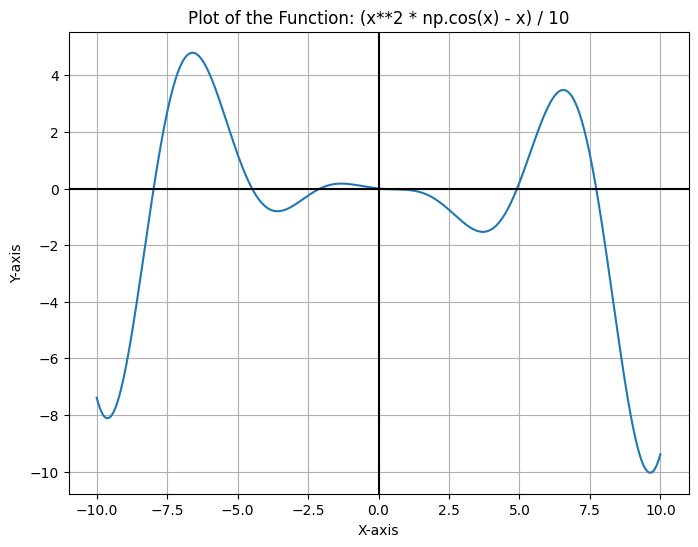

In [34]:
def plot_function(f_input):
    # Plot the function
    x_values = np.linspace(-10, 10, 400)
    y_values = f(x_values)
    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_values, label=f_input)
    # Draw axes through origin
    plt.axhline(0, color='black')
    plt.axvline(0, color='black')
    plt.title(f'Plot of the Function: {f_input}')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True)
    plt.show()

plot_function(f_input)

### 83. Convex Optimization Check

Enter a function `f(x)` and interval `[x1,x2]`. Determine whether the function is convex over that interval.

In [37]:
import numpy as np

def is_convex_function(f, x1, x2, iterations=100, tolerance=1e-9):
    # Lambda is always between 0 and 1
    lambdas = np.linspace(0, 1, iterations)

    for lamb in lambdas:
        f_left = f(lamb * x1 + (1 - lamb) * x2)
        f_right = lamb * f(x1) + (1 - lamb) * f(x2)
        # If this condition breaks the loop, then the function is not convex
        if f_left > f_right + tolerance:  # Add a tolerance
            return False

    return True

In [38]:
f_input = input("Enter equation f(x): ").replace("^", "**")
f = eval(f"lambda x: {f_input}", {"np": np})

x1, x2 = eval(input("Enter x1, x2: "))

# Check for convexity
if is_convex_function(f, x1, x2):
    print(f"The function is convex with x1 = {x1}; x2 = {x2}")
else:
    print("The function is not convex")

Enter equation f(x): x^4-x^2
Enter x1, x2: 2, 3
The function is convex with x1 = 2; x2 = 3


### 84. Hypothesis Testing

Perform hypothesis testing for a population average or proportion using sample data.

In [43]:
def length(x):
    count = 0
    for i in range(len(x)):
        count += 1
    return count


def sample_mean(x):
    return sum(x) / len(x)


def sample_sd(x):
    mean = sample_mean(x)
    total = 0
    for i in range(len(x)):
        total += (x[i] - mean) ** 2

    return (total / (len(x) - 1)) ** 0.5

In [44]:
def alpha(conf):  # Confidence = 1 - alpha
    a = 1 - conf
    return a

def score_both_bounds(conf):  # Find Z score
    a = float(alpha(conf) / 2)
    x = round(1 - a, 4)  # Get up to four decimal places
    # Load Table A1 values
    table = {}

    with open("table a1.txt", "r") as file:
        for line in file:
            z_score, prob = map(float, line.strip().split(","))
            table[prob] = z_score

    # Find the closest probability to x
    closest_prob = min(table.keys(), key=lambda p: abs(p - x))
    z = table[closest_prob]

    return z

def ratio(n, x):  # Estimate point (or ratio)
    # n: total number of samples
    # x: the number of elements that satisfy sample
    f = length(x) / length(n)
    return f

In [45]:
def hypothesis_testing_average(n, x, s, u0, sig):
    t = ((n ** 0.5) / s) * abs(x - u0)  # Find t
    z = score_both_bounds(1 - sig)  # Find the z score using the parameter module

    print(f"t = {t}")
    print(f"z({sig}/2) = {z}")

    if t <= z:  # Not Reject / Accept H0 (u0)
        return True
    else:  # t > z -> Reject H0 / Accept H1: u ≠ u0
        return False

In [46]:
def hypothesis_testing_ratio(n, f, p0, sig):
    t = (n / (p0 * (1 - p0))) ** 0.5 * abs(f - p0)  # Find t
    z = score_both_bounds(1 - sig)  # Find the z score using the parameter module

    print(f"t = {t}")
    print(f"z({sig}/2) = {z}")

    if t <= z:  # Not Reject / Accept H0 (p0)
        return True
    else:  # t > z -> Reject H0 / Accept H1: u ≠ u0
        return False

In [48]:
print("Random Sample Table (Hypothesis Testing Average)")
sequence = []
n = int(input("Enter the length of the table: "))
for i in range(n):
    # Input a value and its frequency
    x, f = eval(input(f"Enter x{i + 1} and its frequency: "))
    for j in range(f):
        sequence.append(x)

# Display the results for the random sample values
n = length(sequence)
x = sample_mean(sequence)
sd = sample_sd(sequence)

# Enter u0 for hypothesis testing problem
print("n:", n)
print("sample mean x:", x)
print("s:", sd)
u0 = float(input("Enter u0: "))

significance = float(input("Enter significance level: "))
t = hypothesis_testing_average(n, x, sd, u0, significance)

if t:  # If is True
    print(f"=> Not Reject H0 / Accept H0: u = {u0}")
else:  # If is False
    print(f"=> Reject H0: u = {u0} / Accept H1: u ≠ {u0}")
    if x < u0:
        print(f"=> Accept u < {u0}")
    else:  # >= 0
        print(f"=> Accept u ≥ {u0}")

Random Sample Table (Hypothesis Testing Average)
Enter the length of the table: 10
Enter x1 and its frequency: 1, 2
Enter x2 and its frequency: 2, 4
Enter x3 and its frequency: 3, 5
Enter x4 and its frequency: 5, 4
Enter x5 and its frequency: 4, 2
Enter x6 and its frequency: 3, 9
Enter x7 and its frequency: 3, 5
Enter x8 and its frequency: 4, 6
Enter x9 and its frequency: 6, 7
Enter x10 and its frequency: 4, 9
n: 53
sample mean x: 3.7169811320754715
s: 1.2461843068183096
Enter u0: 12
Enter significance level: 0.98
t = 48.38873932494983
z(0.98/2) = 0.02
=> Reject H0: u = 12.0 / Accept H1: u ≠ 12.0
=> Accept u < 12.0


In [50]:
# Input table
print("Random Sample Table (Hypothesis Testing Ratio)")
sequence = []
n = int(input("Enter the length of the table: "))

for i in range(n):
    # Input a value and its frequency
    x, f = eval(input(f"Enter x{i + 1} and its frequency: "))
    for j in range(f):
        sequence.append(x)

# Display the results for the random sample values
n = length(sequence)
print("n:", n)

number = int(input("Enter the satisfied number: "))
bound = int(input("Choose bound (0 - Lower; Any key - Higher): "))
x = []

if bound == 0:  # Lower
    for k in range(len(sequence)):
        # Get the number of events satisfying the satisfied number (higher case)
        if sequence[k] < number:
            x.append(sequence[k])
else:  # Higher
    for k in range(len(sequence)):
        # Get the number of events satisfying the satisfied number (lower case)
        if sequence[k] >= number:
            x.append(sequence[k])

print("Number of satisfied elements:", length(x))
f = ratio(sequence, x)  # Get the ratio f
# Enter p0 for hypothesis testing problem
p0 = float(input("Enter p0: "))
significance = float(input("Enter significance level: "))
t = hypothesis_testing_ratio(n, f, p0, significance)

if t:  # If is True
    print(f"=> Not Reject H0 / Accept H0: p = {p0}")
else:  # If is False
    print(f"=> Reject H0: p = {p0} / Accept H1: u ≠ {p0}")
    if f < p0:
        print(f"=> Accept p < {p0}")
    else:  # >= 0
        print(f"=> Accept p ≥ {p0}")

Random Sample Table (Hypothesis Testing Ratio)
Enter the length of the table: 10
Enter x1 and its frequency: 1, 4
Enter x2 and its frequency: 2, 4
Enter x3 and its frequency: 2, 11
Enter x4 and its frequency: 1, 12
Enter x5 and its frequency: 1, 9
Enter x6 and its frequency: 1, 5
Enter x7 and its frequency: 4, 15
Enter x8 and its frequency: 1, 21
Enter x9 and its frequency: 1, 23
Enter x10 and its frequency: 2, 11
n: 115
Enter the satisfied number: 20
Choose bound (0 - Lower; Any key - Higher): 0
Number of satisfied elements: 115
Enter p0: 0.94
Enter significance level: 0.97
t = 2.709321969038545
z(0.97/2) = 0.04
=> Reject H0: p = 0.94 / Accept H1: u ≠ 0.94
=> Accept p ≥ 0.94


### 85. Generate All Permutations

Prompt the user for a size `n` and generate all possible permutations.

In [53]:
def permutation(n, left, right):
    result = []  # List to store all the permutations

    if left == right:
        # Append a copy of the list (to avoid reference issues
        result.append(n[:])
    else:
        for i in range(left, right + 1):
            n[left], n[i] = n[i], n[left]  # Swap
            # Recursively collect permutations
            result += permutation(n, left + 1, right)
            n[left], n[i] = n[i], n[left]  # Backtrack (restore the list)

    return result

In [55]:
def generate_all_permutations(n):
    # Create the initial list of numbers from 1 to n
    initial_list = list(range(1, n + 1))
    # Set start and end boundaries
    return permutation(initial_list, 0, n - 1)

n = int(input("Enter n: "))
for i in generate_all_permutations(n):
  print(i)

Enter n: 5
[1, 2, 3, 4, 5]
[1, 2, 3, 5, 4]
[1, 2, 4, 3, 5]
[1, 2, 4, 5, 3]
[1, 2, 5, 4, 3]
[1, 2, 5, 3, 4]
[1, 3, 2, 4, 5]
[1, 3, 2, 5, 4]
[1, 3, 4, 2, 5]
[1, 3, 4, 5, 2]
[1, 3, 5, 4, 2]
[1, 3, 5, 2, 4]
[1, 4, 3, 2, 5]
[1, 4, 3, 5, 2]
[1, 4, 2, 3, 5]
[1, 4, 2, 5, 3]
[1, 4, 5, 2, 3]
[1, 4, 5, 3, 2]
[1, 5, 3, 4, 2]
[1, 5, 3, 2, 4]
[1, 5, 4, 3, 2]
[1, 5, 4, 2, 3]
[1, 5, 2, 4, 3]
[1, 5, 2, 3, 4]
[2, 1, 3, 4, 5]
[2, 1, 3, 5, 4]
[2, 1, 4, 3, 5]
[2, 1, 4, 5, 3]
[2, 1, 5, 4, 3]
[2, 1, 5, 3, 4]
[2, 3, 1, 4, 5]
[2, 3, 1, 5, 4]
[2, 3, 4, 1, 5]
[2, 3, 4, 5, 1]
[2, 3, 5, 4, 1]
[2, 3, 5, 1, 4]
[2, 4, 3, 1, 5]
[2, 4, 3, 5, 1]
[2, 4, 1, 3, 5]
[2, 4, 1, 5, 3]
[2, 4, 5, 1, 3]
[2, 4, 5, 3, 1]
[2, 5, 3, 4, 1]
[2, 5, 3, 1, 4]
[2, 5, 4, 3, 1]
[2, 5, 4, 1, 3]
[2, 5, 1, 4, 3]
[2, 5, 1, 3, 4]
[3, 2, 1, 4, 5]
[3, 2, 1, 5, 4]
[3, 2, 4, 1, 5]
[3, 2, 4, 5, 1]
[3, 2, 5, 4, 1]
[3, 2, 5, 1, 4]
[3, 1, 2, 4, 5]
[3, 1, 2, 5, 4]
[3, 1, 4, 2, 5]
[3, 1, 4, 5, 2]
[3, 1, 5, 4, 2]
[3, 1, 5, 2, 4]
[3, 4, 1, 2, 5]
[3, 4, 1, 5, 

### 86. Inverse Matrix Using Cofactor Method

Calculate the inverse of a square matrix using cofactors and adjugates.

In [56]:
import numpy as np
from numpy.linalg import det

def inverse_matrix_cofactor(matrix):
    n = len(matrix)
    if n == 0:
        raise ValueError("Empty matrix has no inverse.")
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Matrix must be square to find its inverse.")

    det_matrix = round(det(matrix))
    if det_matrix == 0:
        print("Determinant is 0, the matrix is non-invertible")
        return None

    # Handle 1x1 matrix case separately
    if n == 1:
        return np.array([[1 / matrix[0, 0]]])

    cofactors = []  # Store the cofactors
    for i in range(n):  # Iterate each element in the matrix
        for j in range(n):
            M = np.delete(matrix, i, 0)  # Remove row i
            M = np.delete(M, j, 1)  # Remove column j
            A = ((-1) ** (i + j)) * det(M)
            cofactors.append(round(A))  # Append the cofactors

    # Transpose to get the adjugate matrix
    cofactor_matrix = np.array(cofactors).reshape(n, n)
    adjugate_matrix = np.transpose(cofactor_matrix)

    # Find the inverse matrix
    inverse_matrix = (1 / det_matrix) * adjugate_matrix
    return inverse_matrix

In [59]:
n = int(input("Enter size of the matrix: "))

# Form a matrix of order n
matrix = np.random.randint(0, 10, size=(n, n))
print("Matrix:\n", matrix)

# Calculate and print the inverse matrix
result_inverse_matrix = inverse_matrix_cofactor(matrix)

if result_inverse_matrix is not None:
    print("Inverse Matrix:\n", np.round(result_inverse_matrix, 2))

# Use numpy's inverse function
np_inverse = np.linalg.inv(matrix)
print("\nSolution using NumPy:\n", np.round(np_inverse, 2))

Enter size of the matrix: 5
Matrix:
 [[6 2 8 6 7]
 [4 7 9 1 1]
 [8 0 3 6 2]
 [9 4 1 3 5]
 [2 3 6 0 7]]
Inverse Matrix:
 [[-0.34  0.01  0.36 -0.04  0.26]
 [ 0.3   0.08 -0.43  0.22 -0.35]
 [-0.15  0.06  0.23 -0.17  0.2 ]
 [ 0.49 -0.01 -0.39  0.12 -0.47]
 [ 0.1  -0.08 -0.12  0.07  0.04]]

Solution using NumPy:
 [[-0.34  0.01  0.36 -0.04  0.26]
 [ 0.3   0.08 -0.43  0.22 -0.35]
 [-0.15  0.06  0.23 -0.17  0.2 ]
 [ 0.49 -0.01 -0.39  0.12 -0.47]
 [ 0.1  -0.08 -0.12  0.07  0.04]]


### 87. Social Security Number Validator

Check whether an input follows the valid SSN format.

In [60]:
import string


def number_only(d1, d2, d3):
    d1_list = list(d1)
    d2_list = list(d2)
    d3_list = list(d3)

    string_list_punc = list(string.punctuation)
    string_list_let = list(string.ascii_letters)

    # If any letter is found, the SSN is invalid
    if (any(char in d1_list for char in string_list_let)
            or any(char in d2_list for char in string_list_let)
            or any(char in d3_list for char in string_list_let)):
        return False

    # If punctuation is found, the SSN is invalid
    elif (any(char in d1_list for char in string_list_punc)
          or any(char in d2_list for char in string_list_punc)
          or any(char in d3_list for char in string_list_punc)):
        return False

    else:
        return True

In [61]:
def valid_number(d1, d2, d3):
    # Determine number of digits by counting them
    if d1.count('') != 4 or d2.count('') != 3 or d3.count('') != 5:
        return False
    else:
        return True

In [62]:
d1, d2, d3 = [str(d123) for d123 in (input("Enter Social Security Number: ")).split("-")]

if number_only(d1, d2, d3) is False:
    print("The SSN is Invalid")
    print("Reason: Must only contain digits")
elif valid_number(d1, d2, d3) is False:
    print("The SSN is Invalid")
    print("Reason: Must follow the format ddd-dd-dddd")
else:
    print("The SSN is Valid")

Enter Social Security Number: 123-45-6789
The SSN is Valid


### 88. Word Crush Game

Using `words.txt`, play a word-chain game against the computer. Each new word must start with the last letter of the previous word.

In [63]:
import random

In [64]:
# Load a dictionary for the game
def dictionaries(filename):
    try:
        with open(filename, 'r') as file:
            # Read the file and create a set of words, stripping whitespace
            words = {line.strip().lower() for line in file if line.strip()}
        return words
    except FileNotFoundError:
        print("File not found")

In [65]:
# Computer's logic for words selection
def valid_computer_word(available_words, last_letter):
    # Select a random from the available words that starts with the given letter
    possible_words = [word for word in available_words if word.startswith(last_letter)]

    if possible_words:  # The possible words are found
        return random.choice(possible_words)  # Randomly select one of the possible words
    return None

In [66]:
# Check if the user's word is valid
def is_valid_word(word, used_words, dictionary):
    if word not in dictionary:
        return False
    if word in used_words:
        return False
    return True

In [70]:
def play_word_crush_game():
    used_words = set()  # Keep track of the already used word
    dictionary = dictionaries("words.txt")
    player_turn = False  # This means that the computer will start first
    current_round, max_rounds = 0, 25
    last_letter = ''  # Initialize the last letter

    # The iteration resumes when the current turn
    # has not reached the max turn
    while current_round < max_rounds:
        print(f"Round {current_round + 1} / {max_rounds}")

        for turn in range(2):  # Each round has two turns
            # The user's turn
            if player_turn:
                player_word = str(input("(Player) Enter a word: "))
                word = player_word.lower()  # Put the word in lowercase for consideration
                # The word is not alphabetical (contains special symbols)
                if not word.isalpha():
                    print("The word is invalid. You Lose!!")
                    return

                # If the word is either already used or not in the dictionary
                if not is_valid_word(player_word, used_words, dictionary):
                    print("The word is already used or not meaningful. You Lose!!")
                    return

                # If the first letter of the word
                # is not the last letter of the computer's word
                if last_letter and player_word[0] != last_letter:
                    print(f"The word does not start with '{last_letter}'. You Lose!!")
                    return

                # Save the input word to the set
                used_words.add(player_word)
                last_letter = player_word[-1]  # Get the last letter of the word

            else:
                # Starts with the computer
                # Make sure the computer does not select an already used word
                computer_word = valid_computer_word(dictionary - used_words, last_letter)
                if computer_word is not None:  # If the computer has a word to play
                    print(f"(Computer) Computer played: {computer_word}")
                    used_words.add(computer_word)  # Save the word to the set
                    last_letter = computer_word[-1]  # Get the last letter of the word
                else:
                    print("The computer has no word to play. You won!!")
                    return

            # Switch turn between the user and the computer
            player_turn = not player_turn

        # Update number of round
        current_round += 1

    # The loop ends when it reaches the max_round, thereby, display the result
    if current_round == max_rounds:
        print("=> Game over. It is a draw!!")
    else:  # In case the game ends early, either the player
        # Or the computer loses immediately
        print("=> Game ends early")

play_word_crush_game()

Round 1 / 25
(Computer) Computer played: smalmed
(Player) Enter a word: damsel
Round 2 / 25
(Computer) Computer played: lauryn
(Player) Enter a word: no
Round 3 / 25
(Computer) Computer played: overcapitalizes
(Player) Enter a word: sympathize
Round 4 / 25
(Computer) Computer played: efta
(Player) Enter a word: attractive
Round 5 / 25
(Computer) Computer played: eggeater
(Player) Enter a word: rage
Round 6 / 25
(Computer) Computer played: ezba
(Player) Enter a word: apart
Round 7 / 25
(Computer) Computer played: tabulare
(Player) Enter a word: erostic
The word is already used or not meaningful. You Lose!!


### 89. Random Letter Words Game

Using the same `words.tx`t file. Play the following word game: A random letter is chosen. Enter a meaningful word containing that letter.

In [ ]:
import string
import random

In [ ]:
def dictionaries(filename):  # Load a dictionary for the game
    try:
        with open(filename, 'r') as file:
            # Read the file and create a set of words, stripping whitespace
            words = {line.strip().lower() for line in file if line.strip()}
        return words
    except FileNotFoundError:
        print("File not found")

In [72]:
def play_random_letter_word_game():
    used_words = set()  # Keep track of the already used word
    dictionary = dictionaries("words.txt")
    selected_letter = random.choice(string.ascii_uppercase)
    letter = selected_letter.lower()

    print(f"Your letter is {selected_letter}")

    # Play word game
    count = 0

    for i in range(1, 101):
        input_word = input(f"{i}. Enter a word: ")
        word = input_word.lower()  # Put the word in lowercase for consideration

        if not word: # Handle empty input
            print("=" * 50)
            print("=> Empty input. You Lose!!")
            return
        if word in used_words:
            print("=" * 50)
            print("=> Duplicate Word\nYou Lose!!")
            return
        elif letter not in word:
            print("=" * 50)
            print("=> Invalid Word (does not contain the letter)\nYou Lose!!")
            return
        elif word not in dictionary:
            print("=" * 50)
            print("=> Not Meaningful Word\nYou Lose!!")
            return
        else:
            print("=> Correct! Keep going.")
            used_words.add(word)
            count += 1

    print("=" * 50)
    print(f"=> Congratulations! You found {count} words and won!")

play_random_letter_word_game()

Your letter is Z
1. Enter a word: zigzag
=> Correct! Keep going.
2. Enter a word: zone
=> Correct! Keep going.
3. Enter a word: zodiac
=> Correct! Keep going.
4. Enter a word: jazz
=> Correct! Keep going.
5. Enter a word: daz
=> Not Meaningful Word
You Lose!!


### 90. Most Frequent Word in Egypt Text

Create `egypt.txt`, read the text, count word frequencies, and find the most common word.

In [73]:
import string

text = ("Egypt is a developing country with the second-largest economy in Africa. "
        "It is considered to be a regional power in the Middle East, North Africa and the Muslim world, "
        "and a middle power worldwide. "
        "Islam is the official religion and Arabic is official language.")

text = text.translate(str.maketrans('', '', string.punctuation))

In [74]:
# Write the file
with open("egypt.txt", "w") as f:
    f.write(text.lower())

text_list = []  # The list to obtain the word from the text
text_dict = {}  # The dictionary

with open("egypt.txt", "r") as read_file:
    for read in read_file:
        # Iterate through each text in the file
        for text in read.split():
            text_list.append(text)

In [75]:
# Iterate through each word in the list to find its occurrence
for i in text_list:
    # Append to the dictionary
    text_dict[i] = text_list.count(i)

# Show the dictionary
print("All words and their occurrence:")
for key, values in text_dict.items():
    print(f"+ Word: {key}, Count: {values}")

# Get max values
max_values = max(text_dict.values())

# Find the word with most count and return it
print("Words with maximum occurrence")
for key, values in text_dict.items():
    if values == max_values:
        print(f"+ Word: {key}, Count: {values}")

All words and their occurrence:
+ Word: egypt, Count: 1
+ Word: is, Count: 4
+ Word: a, Count: 3
+ Word: developing, Count: 1
+ Word: country, Count: 1
+ Word: with, Count: 1
+ Word: the, Count: 4
+ Word: secondlargest, Count: 1
+ Word: economy, Count: 1
+ Word: in, Count: 2
+ Word: africa, Count: 2
+ Word: it, Count: 1
+ Word: considered, Count: 1
+ Word: to, Count: 1
+ Word: be, Count: 1
+ Word: regional, Count: 1
+ Word: power, Count: 2
+ Word: middle, Count: 2
+ Word: east, Count: 1
+ Word: north, Count: 1
+ Word: and, Count: 3
+ Word: muslim, Count: 1
+ Word: world, Count: 1
+ Word: worldwide, Count: 1
+ Word: islam, Count: 1
+ Word: official, Count: 2
+ Word: religion, Count: 1
+ Word: arabic, Count: 1
+ Word: language, Count: 1
Words with maximum occurrence
+ Word: is, Count: 4
+ Word: the, Count: 4


### 91. Currency Denomination Counter

Given an amount of money, determine the minimum number of bills needed using denominations: `$1, $2, $5, $10, $25, $50, $100`.

In [76]:
def count_denominations(amount):
    denominations = {100: 0, 50: 0, 25: 0, 10: 0,
                     5: 0, 2: 0, 1: 0}

    remaining_amount = amount

    if remaining_amount >= 100:
        denominations[100] = remaining_amount // 100
        remaining_amount %= 100
    if remaining_amount >= 50:
        denominations[50] = remaining_amount // 50
        remaining_amount %= 50
    if remaining_amount >= 25:
        denominations[25] = remaining_amount // 25
        remaining_amount %= 25
    if remaining_amount >= 10:
        denominations[10] = remaining_amount // 10
        remaining_amount %= 10
    if remaining_amount >= 5:
        denominations[5] = remaining_amount // 5
        remaining_amount %= 5
    if remaining_amount >= 2:
        denominations[2] = remaining_amount // 2
        remaining_amount %= 2
    if remaining_amount >= 1:
        denominations[1] = remaining_amount // 1
        remaining_amount %= 1

    return denominations

In [81]:
cost = int(input("Enter the cost of the item: "))

if cost < 1:
    print("No suitable amount")
else:
    print(f"${cost} requires: ")
    denomination_counts = count_denominations(cost)

    # Display the nonzero denominations
    if denomination_counts[100] >= 1:
        print(f"* {denomination_counts[100]} bills of 100$")
    if denomination_counts[50] >= 1:
        print(f"* {denomination_counts[50]} bills of 50$")
    if denomination_counts[25] >= 1:
        print(f"* {denomination_counts[25]} bills of 25$")
    if denomination_counts[10] >= 1:
        print(f"* {denomination_counts[10]} bills of 10$")
    if denomination_counts[5] >= 1:
        print(f"* {denomination_counts[5]} bills of 5$")
    if denomination_counts[2] >= 1:
        print(f"* {denomination_counts[2]} bills of 2$")
    if denomination_counts[1] >= 1:
        print(f"* {denomination_counts[1]} bills of 1$")

Enter the cost of the item: 2521
$2521 requires: 
* 25 bills of 100$
* 2 bills of 10$
* 1 bills of 1$


### 92. Japanese Dictionary (Tkinter + Jisho API)

Create a simple GUI dictionary using Tkinter. Enter a Japanese or English word and display definitions from the Jisho API.

In [ ]:
import tkinter as tk
from tkinter import messagebox
import requests

In [ ]:
# Function to query Jisho API
def search_word():
    word = entry.get()
    if not word:
        messagebox.showerror("Error", "Please enter a word to search")
        return

    try:
        response = requests.get(f"https://jisho.org/api/v1/search/words?keyword={word}")
        response.raise_for_status()
        data = response.json()
        if data['data']:
            meaning = data['data'][0]['senses'][0]['english_definitions']
            result = ', '.join(meaning)
            result_label.config(text=f"Meaning: {result}")
        else:
            result_label.config(text="No results found")
    except Exception as e:
        messagebox.showerror("Error", f"Failed to fetch data: {e}")

In [ ]:
# Creating the main window
root = tk.Tk()
root.title("Japanese Dictionary")
root.resizable(False, False)

# Creating widgets
entry_label = tk.Label(root, text="Enter Japanese Word:")
entry_label.pack(pady=5)

entry = tk.Entry(root, width=40)
entry.pack(pady=5)

search_button = tk.Button(root, text="Search", command=search_word)
search_button.pack(pady=5)

result_label = tk.Label(root, text="", wraplength=300, justify="left")
result_label.pack(pady=10)

# Running the application
root.mainloop()

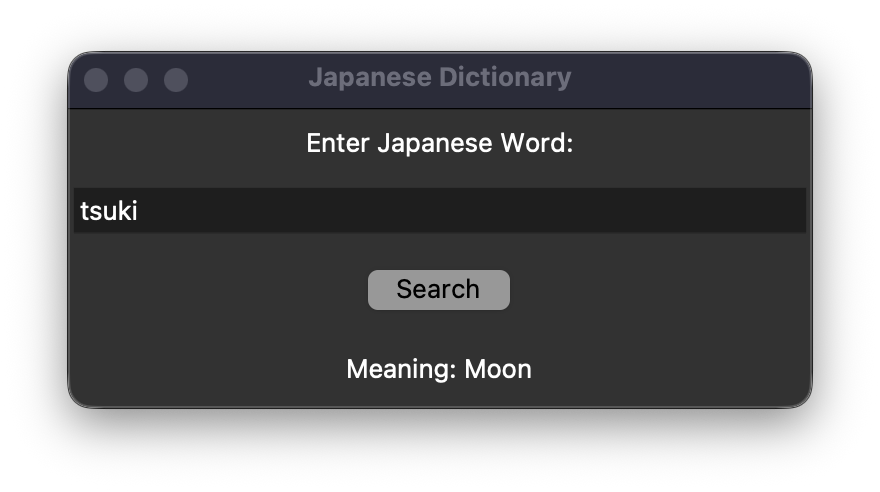

### 93. Tic-Tac-Toe Game

Create a two-player Tic-Tac-Toe game played on a 3×3 grid.

In [82]:
def game_board(b):
    for i in range(len(b)):
        print('   '.join(b[i]))

In [83]:
def player_move(b):
    valid_column = [0, 1, 2]

    while True:
        row, col = eval(input("Enter the row (0,1,2) and column (0,1,2): "))
        if (row not in valid_column) or (col not in valid_column):
            print("Invalid Move. Please enter again")
        elif b[row][col] != '-':
            print("Already Filled. Please enter again")
        else:
            return row, col

In [84]:
def check_winner(b):
    # Check for Row
    for row in b:
        if all(cell == 'X' for cell in row):
            return 'X'
        elif all(cell == 'O' for cell in row):
            return 'O'

    # Check for Column
    for col in range(3):
        if all(b[row][col] == 'X' for row in range(3)):
            return 'X'
        elif all(b[row][col] == 'O' for row in range(3)):
            return 'O'

    # Check for Diagonal
    if all(b[i][i] == 'X' for i in range(3)) or all(b[i][2 - i] == 'X' for i in range(3)):
        return 'X'
    elif all(b[i][i] == 'O' for i in range(3)) or all(b[i][2 - i] == 'O' for i in range(3)):
        return 'O'

    return None  # No winner

In [85]:
def check_draw(b):
    return all(cell != '-' for row in b for cell in row)


def update_board(row, col, player, b):
    b[row][col] = player

In [87]:
def play_tic_tac_toe_game():
    b = [['-', '-', '-'], ['-', '-', '-'], ['-', '-', '-']]
    max_moves = 9  # Maximum move for a 3x3 board
    player_turn = True

    for move in range(max_moves):
        # Call player's turn
        player = 'X' if player_turn else 'O'
        print(f"Player {player}'s turn")

        # Call the input and display function
        row, col = player_move(b)
        update_board(row, col, player, b)
        game_board(b)

        # Call the validate function
        if check_winner(b) == player:
            print(f"Game Over. {player} won")
            break
        elif check_draw(b):
            print("Game Over. It is a Draw")
            break

        # Switch the player's turn
        player_turn = not player_turn

play_tic_tac_toe_game()

Player X's turn
Enter the row (0,1,2) and column (0,1,2): 0, 1
-   X   -
-   -   -
-   -   -
Player O's turn
Enter the row (0,1,2) and column (0,1,2): 1, 1
-   X   -
-   O   -
-   -   -
Player X's turn
Enter the row (0,1,2) and column (0,1,2): 0, 2
-   X   X
-   O   -
-   -   -
Player O's turn
Enter the row (0,1,2) and column (0,1,2): 1, 0
-   X   X
O   O   -
-   -   -
Player X's turn
Enter the row (0,1,2) and column (0,1,2): 0, 0
X   X   X
O   O   -
-   -   -
Game Over. X won


### 94. Connect Four

Create the Connect Four game where players drop pieces into a 7×6 board. First to connect four pieces wins.

In [88]:
import numpy as np

# Row and column board in Connect Four
row_board = 6
column_board = 7

def create_board():  # Create the game board
    board = np.zeros((row_board, column_board))
    return board


def drop_piece(board, move_row, move_col, piece):  # Drop the piece in the board
    board[move_row][move_col] = piece


def is_valid_location(board, move_col):  # Check if the location is valid
    return board[row_board - 1][move_col] == 0


def get_next_open_row(board, move_col):  # Get the next open row
    for r in range(row_board):
        if board[r][move_col] == 0:
            return r

def print_board(board):  # Flip the board
    print(np.flip(board, 0))

In [89]:
def winning_move(board, piece):
    # Check horizontal locations
    for c in range(column_board - 3):
        for r in range(row_board):
            if ((board[r][c] == piece) and (board[r][c + 1] == piece)
                    and (board[r][c + 2] == piece) and (board[r][c + 3] == piece)):
                return True

    # Check vertical locations
    for c in range(column_board):
        for r in range(row_board - 3):
            if ((board[r][c] == piece) and (board[r + 1][c] == piece)
                    and (board[r + 2][c] == piece) and (board[r + 3][c] == piece)):
                return True

    # Check positive diagonals
    for c in range(column_board - 3):
        for r in range(row_board - 3):
            if ((board[r][c] == piece) and (board[r + 1][c + 1] == piece)
                    and (board[r + 2][c + 2] == piece) and (board[r + 3][c + 3] == piece)):
                return True

    # Check negative diagonals
    for c in range(column_board - 3):
        for r in range(3, row_board):
            if ((board[r][c] == piece) and (board[r + 1][c + 1] == piece)
                    and (board[r + 2][c + 2] == piece) and (board[r + 3][c + 3] == piece)):
                return True

In [90]:
def play_connect_four_game():
    game_board = create_board()
    game_over = False
    player = 0
    turn = 0

    while not game_over:
        # Player 1 Input
        if turn == 0:
            col = int(input("Player 1 Make your selection (0-6): "))
            # Invalid input causes the opponent to win
            if col > 6 or col < 0:
                print("Invalid input. Player 2 wins!!")
                break
            # Check for validation, then drop the piece to the board
            if is_valid_location(game_board, col):
                row = get_next_open_row(game_board, col)
                drop_piece(game_board, row, col, 1)
                # Check for possible win move and update the status
                if winning_move(game_board, 1):
                    player = 1
                    game_over = True
            else:
                print("Invalid location. Try again.")
                continue

        # Player 2 Input
        else:
            col = int(input("Player 2 Make your selection (0-6): "))
            # Invalid input causes the opponent to win
            if col > 6 or col < 0:
                print("Invalid input. Player 1 wins!!")
                break
            # Check for validation, then drop the piece to the board
            if is_valid_location(game_board, col):
                row = get_next_open_row(game_board, col)
                drop_piece(game_board, row, col, 2)
                # Check for possible win move and update the status
                if winning_move(game_board, 2):
                    player = 2
                    game_over = True
            else:
                print("Invalid location. Try again.")
                continue

        # Update the game board
        print_board(game_board)

        # Switch turn
        turn += 1
        turn = turn % 2

    # Display the final result
    if game_over:
        print(f"Game Over. Player {player} wins!!")

play_connect_four_game()

Player 1 Make your selection (0-6): 1
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]]
Player 2 Make your selection (0-6): 2
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 2. 0. 0. 0. 0.]]
Player 1 Make your selection (0-6): 3
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 2. 1. 0. 0. 0.]]
Player 2 Make your selection (0-6): 4
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 2. 1. 2. 0. 0.]]
Player 1 Make your selection (0-6): 5
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 2. 1. 2. 1. 0.]]
Player 2 Make your selection (0-6): 3
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]

### 95. Probability Threshold Selection

Given:

- Probability of success for one trial = `p`
- Target probability = `M`

Find the minimum number of selections `n` such that the probability of at least one success is greater than or equal to `M`.

In [93]:
def find_min_selections(maximum, p):
    n = 1  # Initialize n (number of trials)

    # We need P(X >= 1) >= maximum, where P(X >= 1) is the probability of at least one success.
    # P(X >= 1) = 1 - P(X = 0)
    # P(X = 0) is the probability of zero successes in n trials, which is (1-p)^n.
    while True:
        prob_at_least_one_success = 1 - ((1 - p) ** n)

        if prob_at_least_one_success >= maximum:
            return n, prob_at_least_one_success
        n += 1

In [94]:
maximum = float(input("Enter target probability (between 0 and 1): "))

if not (0 <= maximum <= 1):
    print("Error: Target probability must be between 0 and 1.")
else:
    p = float(input("Enter probability of one trial p (between 0 and 1): "))
    if not (0 <= p <= 1):
        print("Error: Probability of one trial p must be between 0 and 1.")
    elif p == 0:
        print("Error: Probability of success cannot be zero.")
    else:
        n_min, actual_prob = find_min_selections(maximum, p)
        print("The maximum probability is reached when:")
        print(f"n = {n_min} => P(at least one success) = {actual_prob:.6f}")

Enter target probability (between 0 and 1): 0.95
Enter probability of one trial p (between 0 and 1): 0.12
The maximum probability is reached when:
n = 24 => P(at least one success) = 0.953486


### 96. Credit Card Number Validator

Validate a credit card number using the Luhn Algorithm. Also determine whether the card is Visa, MasterCard, American Express, or other.

In [95]:
def is_valid(number):
    number = int(number)
    separate = 0
    count = 0
    number_list = []
    valid_count = (13, 14, 15, 16)  # Valid number is between 13 and 16 digits

    while number > 0:
        digit = number % 10
        digit += separate
        number = number // 10
        number_list.append(digit)  # Make a list contains the digits
        count += 1  # Count the digits

    if count > 16:
        return False
    elif count in valid_count:
        return True

In [96]:
def get_digit(number):  # Define function to get digits from even numbers
    total = number * 2

    if total >= 10:
        digit1 = total % 10
        digit2 = total // 10
        total = digit1 + digit2

    return total

In [97]:
def sum_of_double_even_place(number):
    if is_valid(number) is True:
        total_list = []
        count = 0

        while number > 0:  # Reverse the number
            digit = number % 10
            number = number // 10
            count += 1
            if (count % 2) == 0:
                total_list.append(get_digit(digit))  # Make a list contain the even digits

        return sum(total_list)

In [98]:
def sum_of_odd_place(number):
    odd_list = []
    count = 0

    while number > 0:  # Reverse the number
        digit = number % 10
        number = number // 10
        count += 1
        if (count % 2) != 0:
            odd_list.append(digit)  # Make a list contain the odd digits

    return sum(odd_list)

In [99]:
# This special function sums the result of total list and odd list
def final_sum(number):
    total_list = sum_of_double_even_place(number)
    even_list = sum_of_odd_place(number)
    result = total_list + even_list

    if result % 10 == 0:
        return True


def prefix_matched(number, d):
    num_str = str(number)
    prefix = str(d)  # The prefix is the first digit of the number

    return num_str.startswith(prefix)   # Use this function


def get_size(d):
    return len(str(d))


def get_prefix(number, k):  # Define function to get the prefix
    num_str = str(number)

    if len(num_str) < k:
        return number

    return int(num_str[:k])

In [101]:
def credit_card_validation():
    number = str(input("Enter a card number: "))
    number_list = list(number)

    # Check distinctively for number 0
    if number_list[0] == '0' and is_valid(number) is not True:
        print("The Card is Invalid\nCard Number should have between 13 and 16 digits.")

    elif number_list[0] == '0':
        print("The Card is Invalid\nCard Number should start with the following")
        print("4 for Visa Card\n5 for MasterCard credit cards\n37 for American Express cards\n6 for Discover cards")

    else:
        number = int(number)

        # Check for all the invalid cases
        if is_valid(number) is not True:
            print("The Card is Invalid\nCard Number should have between 13 and 16 digits.")

        elif (not prefix_matched(number, '4')
              and not prefix_matched(number, '5') and not prefix_matched(number, '37')
              and not prefix_matched(number, '6')):
            print("The Card is Invalid\nCard Number should start with the following")
            print("4 for Visa Card\n5 for MasterCard credit cards\n37 for American Express cards\n6 for Discover cards")

        elif final_sum(number) is not True:
            print("The Card is Invalid\nThe result is not divisible by 10")

        else:
            # Display if the number is valid
            print("The Card is Valid")
            if prefix_matched(number, '4'):
                print("Card Type: Visa")
            elif prefix_matched(number, '5'):
                print("Card Type: MasterCard")
            elif prefix_matched(number, '37'):
                print("Card Type: American Express")
            elif prefix_matched(number, '6'):
                print("Card Type: Discover")


credit_card_validation()

Enter a card number: 4532015112830366
The Card is Valid
Card Type: Visa


### 97. Student Semester Grade Evaluation

Enter averages for 12 subjects and the PE result. Determine the final academic status according to the decision table.

In [102]:
def get_subject_scores(subjects):
    first_list, mid_list, final_list = [], [], []
    print("Enter your scores below (First Term, Mid Term, Final Term):")

    for i in subjects:
        first, mid, final = eval(input(f"  + {i}: "))
        first_list.append(first)
        mid_list.append(mid)
        final_list.append(final)
    pe = input("+ PE: Pass or Fail? ")

    return first_list, mid_list, final_list, pe

In [103]:
def validate_scores(first_list, mid_list, final_list, pe_input):
    pe_status_valid = ["Pass", "P", "PASS", "pass", "p",
                       "Fail", "F", "FAIL", "fail", "f"]

    if pe_input not in pe_status_valid:
        print("Error: Invalid PE Input. Please proceed and try again.")
        return False

    elif (any(fir > 10 or fir < 0 for fir in first_list) or
          any(mid > 10 or mid < 0 for mid in mid_list) or
          any(fin > 10 or fin < 0 for fin in final_list)):
        print("Error: Invalid Score Input (scores must be between 0 and 10). Please proceed and try again.")
        return False

    return True

In [104]:
def calculate_averages(first_list, mid_list, final_list):
    average_list = []

    for i in range(len(first_list)):
        average = (first_list[i] + mid_list[i] * 2 + final_list[i] * 3) / 6
        average_list.append(average)

    return average_list

In [105]:
def determine_academic_status(total_average, average_list, pe):
    status_list = ["EXCELLENT", "GOOD", "INTERMEDIATE", "MARGINAL", "FAIL"]
    status = ""

    if total_average >= 8.0:
        if any(aver < 6.5 for aver in average_list):
            status = status_list[1]
        elif pe.lower() in ["fail", "f"]:
            status = status_list[2]
        else:
            status = status_list[0]

    elif total_average >= 6.5:
        if any(aver < 5.0 for aver in average_list):
            status = status_list[2]
        elif pe.lower() in ["fail", "f"]:
            status = status_list[3]
        else:
            status = status_list[1]

    elif total_average >= 5.0:
        if any(aver < 3.5 for aver in average_list):
            status = status_list[3]
        elif pe.lower() in ["fail", "f"]:
            status = status_list[4]
        else:
            status = status_list[2]

    elif total_average >= 3.5:
        if any(aver < 2.0 for aver in average_list):
            status = status_list[4]
        elif pe.lower() in ["fail", "f"]:
            status = status_list[4]
        else:
            status = status_list[3]

    else:
        status = status_list[4]

    return status

In [106]:
def display_report_card(subjects, first_list, mid_list, final_list, average_list, pe_input, total_average, status):
    print("\n\t\t\t\t\t\t\t\tReport Card\t\t\t\t\t")
    print("=" * 100)
    print('{:<20}{:<15}{:<15}{:<16}{:<20}'.format("Subject", "First Term", "Mid Term", "Final Term", "Average"))
    print("=" * 100)

    for j in range(len(subjects)):
        print('{:<25}{:<15.1f}{:<15.1f}{:<15.1f}{:<15.1f}'.format(subjects[j], first_list[j], mid_list[j], final_list[j], average_list[j]))

    print("{:<25}{:<15}".format("PE", pe_input))
    print("\nTotal Average: ", f"{total_average: .1f}")
    print(f"Status: {status}")

In [108]:
def student_grade():
    subjects = ["Math", "Literature", "English", "Physics",
                "Chemistry", "Biology", "History",
                "Geography", "Civics", "Computer Science",
                "Technology", "Musics & Arts"]

    print("Final Semester")
    first_list, mid_list, final_list, pe_input = get_subject_scores(subjects)

    if validate_scores(first_list, mid_list, final_list, pe_input):
        average_list = calculate_averages(first_list, mid_list, final_list)
        total_average = sum(average_list) / len(subjects)
        status = determine_academic_status(total_average, average_list, pe_input)
        display_report_card(subjects, first_list, mid_list, final_list, average_list, pe_input, total_average, status)


student_grade()

Final Semester
Enter your scores below (First Term, Mid Term, Final Term):
  + Math: 9, 9.5, 9.3
  + Literature: 7.8,7.6, 8.0
  + English: 8.8,8.1,8.3
  + Physics: 7.8,7.3,8.1
  + Chemistry: 8.9,8.3,7.5
  + Biology: 8,8,8.1
  + History: 9,8,7.8
  + Geography: 9,9,9
  + Civics: 9,10,10
  + Computer Science: 10,10,10
  + Technology: 8,10,7.8
  + Musics & Arts: 10,10,9
+ PE: Pass or Fail? Pass

								Report Card					
Subject             First Term     Mid Term       Final Term      Average             
Math                     9.0            9.5            9.3            9.3            
Literature               7.8            7.6            8.0            7.8            
English                  8.8            8.1            8.3            8.3            
Physics                  7.8            7.3            8.1            7.8            
Chemistry                8.9            8.3            7.5            8.0            
Biology                  8.0            8.0            8.1     

### 98. Tax Table Generator

Display a tax table showing taxable income, tax rate, and tax amount for a range of incomes.

In [109]:
def compute_tax(status, taxable_income):  # Define function
    # Compute tax
    if status == 0:  # Compute tax for single filers
        if taxable_income <= 8350:
            tax = taxable_income * 0.10
            return round(tax)

        elif taxable_income <= 33950:
            tax = 8350 * 0.10 + (taxable_income - 8350) * 0.15
            return round(tax)

        elif taxable_income <= 82250:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (taxable_income - 33950) * 0.25)
            return round(tax)

        elif taxable_income <= 171550:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (82250 - 33950) * 0.25 + (taxable_income - 82250) * 0.28)
            return round(tax)

        elif taxable_income <= 372950:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (82250 - 33950) * 0.25 + (171550 - 82250) * 0.28 +
                   (taxable_income - 171550) * 0.33)
            return round(tax)

        else:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (82250 - 33950) * 0.25 + (171550 - 82250) * 0.28 +
                   (372950 - 171550) * 0.33 + (taxable_income - 372950) * 0.35)
            return round(tax)

    if status == 1:  # Compute tax for married jointly
        if taxable_income <= 16700:
            tax = taxable_income * 0.10
            return round(tax)

        elif taxable_income <= 67900:
            tax = 16700 * 0.10 + (taxable_income - 16700) * 0.15
            return round(tax)

        elif taxable_income <= 137050:
            tax = (16700 * 0.10 + (67900 - 16700) * 0.15 +
                   (taxable_income - 67900) * 0.25)
            return round(tax)

        elif taxable_income <= 208850:
            tax = (16700 * 0.10 + (67900 - 16700) * 0.15 +
                   (137050 - 67900) * 0.25 + (taxable_income - 137050) * 0.28)
            return round(tax)

        elif taxable_income <= 372950:
            tax = (16700 * 0.10 + (67900 - 16700) * 0.15 +
                   (137050 - 67900) * 0.25 + (208850 - 137050) * 0.28 +
                   (taxable_income - 208850) * 0.33)
            return round(tax)

        else:
            tax = (16700 * 0.10 + (67900 - 16700) * 0.15 +
                   (137050 - 67900) * 0.25 + (208850 - 137050) * 0.28 +
                   (372950 - 208850) * 0.33 + (taxable_income - 372950) * 0.35)
            return round(tax)

    if status == 2:  # Compute tax for married separately
        if taxable_income <= 8350:
            tax = taxable_income * 0.10
            return round(tax)

        elif taxable_income <= 33950:
            tax = 8350 * 0.10 + (taxable_income - 8350) * 0.15
            return round(tax)

        elif taxable_income <= 68525:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (taxable_income - 33950) * 0.25)
            return round(tax)

        elif taxable_income <= 104425:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (68525 - 33950) * 0.25 + (taxable_income - 68525) * 0.28)
            return round(tax)

        elif taxable_income <= 186475:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (68525 - 33950) * 0.25 + (104425 - 68525) * 0.28 +
                   (taxable_income - 104425) * 0.33)
            return round(tax)

        else:
            tax = (8350 * 0.10 + (33950 - 8350) * 0.15 +
                   (68525 - 33950) * 0.25 + (104425 - 68525) * 0.28 +
                   (186475 - 104425) * 0.33 + (taxable_income - 186475) * 0.35)
            return round(tax)

    if status == 3:  # Compute tax for head of household
        if taxable_income <= 11950:
            tax = taxable_income * 0.10
            return round(tax)

        elif taxable_income <= 45500:
            tax = 11950 * 0.10 + (taxable_income - 11950) * 0.15
            return round(tax)

        elif taxable_income <= 117450:
            tax = (11950 * 0.10 + (45500 - 11950) * 0.15 +
                   (taxable_income - 45500) * 0.25)
            return round(tax)

        elif taxable_income <= 190200:
            tax = (11950 * 0.10 + (45500 - 11950) * 0.15 +
                   (117450 - 45500) * 0.25 + (taxable_income - 117450) * 0.28)
            return round(tax)

        elif taxable_income <= 372950:
            tax = (11950 * 0.10 + (45500 - 11950) * 0.15 +
                   (117450 - 45500) * 0.25 + (190200 - 117450) * 0.28 +
                   (taxable_income - 190200) * 0.33)
            return round(tax)

        else:
            tax = (11950 * 0.10 + (45500 - 11950) * 0.15 +
                   (117450 - 45500) * 0.25 + (190200 - 117450) * 0.28 +
                   (372950 - 190200) * 0.33 + (taxable_income - 372950) * 0.35)
            return round(tax)

In [111]:
print("Tax Table")
print("Taxable Income\tSingle\tMarried Joint\tMarried Sep.\tHead of House")

# Assume the value for the table
tax_income = 49950

# Display the table
for table in range(1, 202):
  tax_income = tax_income + 50
  status = 0

  print("{:<20}{:<15}".format(tax_income, compute_tax(status, tax_income)), end="")
  status = 1

  print("{:<18}".format(compute_tax(status, tax_income)), end="")
  status = 2

  print("{:<16}".format(compute_tax(status, tax_income)), end="")
  status = 3

  print("{:<15}".format(compute_tax(status, tax_income)))

Tax Table
Taxable Income	Single	Married Joint	Married Sep.	Head of House
50000               8688           6665              8688            7352           
50050               8700           6672              8700            7365           
50100               8712           6680              8712            7378           
50150               8725           6688              8725            7390           
50200               8738           6695              8738            7402           
50250               8750           6702              8750            7415           
50300               8762           6710              8762            7428           
50350               8775           6718              8775            7440           
50400               8788           6725              8788            7452           
50450               8800           6732              8800            7465           
50500               8812           6740              8812            7478    

### 99. Password Validator

Check whether a password satisfies all requirements:

- At least 8 characters
- Contains only letters and digits
- Contains at least 2 digits

In [112]:
import string

In [113]:
def valid_characters(password):
    if password.count("") < 9:
        return False
    else:
        return True

In [114]:
def letters_and_digits(password):  # Define function for only letters and digits
    list_password = list(password)
    list_punc = list(string.punctuation)

    if any(punc in list_password for punc in list_punc):
        return False
    else:
        return True

In [115]:
def two_digits(password):  # Define function to check the number of digits
    count = 0

    list_password = list(password)
    list_dig = list(string.digits)

    for dig in list_password:
        if dig in list_dig:
            count += 1

    if count < 2:
        return False
    else:
        return True

In [118]:
def check_password():
    password = str(input("Password: "))

    if valid_characters(password) is False:
        print("Invalid Password")
        print("Reason: Must have at least eight characters")

    elif letters_and_digits(password) is False:
        print("Invalid Password")
        print("Reason: Must only contain letters and digits")

    elif two_digits(password) is False:
        print("Invalid Password")
        print("Reason: Must contain at least two digits")

    else:
        print("Confirmed. Valid Password")

check_password()

Password: Alice1342
Confirmed. Valid Password


### 100. Partially Ordered Relation (POSET)

Given a relation on a set, determine whether it is a Partially Ordered Set (POSET).

In [119]:
def get_all_order_pairs(set_items):
    n = len(set_items)
    order_pairs = set()
    for i in range(n):
        for j in range(n):
            order_pairs.add((int(set_items[i]), int(set_items[j])))
    return order_pairs


def get_sub_order_pairs(number, set_items):
    # Get subsets of ordered pairs by the user
    # and create the relation
    order_pair_sets = get_all_order_pairs(set_items)
    sub_set = set()  # Initialize
    for i in range(number):
        while True:
            sub = input(f"Enter pair {i + 1}: ").split(",")
            sub_S = tuple(int(s) for s in sub)  # Convert to tuple
            if sub_S in order_pair_sets:
                sub_set.add(sub_S)  # Add the tuples to the set
                break
            else:
                print("The pair does not exist in the set")
    return sub_set  # Return the relation (set of tuples)


def check_reflexive(order_pairs, relation_set):  # Check for reflexive
    # The relation is reflexive when there exists all pairs (a, b)
    # With a = b {note that a, b must be in set X} => pair (a, a)
    for i in order_pairs:
        # If there is any missing value (a, a) in the relation
        if i[0] == i[1] and i not in relation_set:
            return False
    return True


def check_antisymmetric(relation_set):  # Check for antisymmetric
    # The relation is antisymmetric when there does not exist
    # any pair (a, b) and (b, a) with a ≠ b
    # {note that a, b must be in set X}
    for i in relation_set:
        # If the reverse of the tuple exists in the relation
        # And no pair (a, a) exists in the relation
        if i[::-1] in relation_set and i[0] != i[1]:
            return False
    return True


def check_transitive(relation_set):  # Check for transitive
    # The relation is transitive when: if there exists pair (a, b) and (b, c)
    # there exists a pair (a, c) {note that a, b must be in set X}
    for i in relation_set:
        for j in relation_set:
            # If there exists two pairs
            # that the index 0 of pair 1 == index 1 of pair 2
            # And there does not exist the transitive pair in the relation
            if i[1] == j[0] and (i[0], j[1]) not in relation_set:
                return False
    return True

In [120]:
def check_poset():
    set_input = input("Enter the elements of the set (comma-separated, e.g., 1,2,3): ").split(', ')
    set_items = [item.strip() for item in set_input]

    all_order_pairs = set()
    for x in set_items:
        for y in set_items:
            all_order_pairs.add((int(x), int(y)))

    num_pairs = int(input("Enter the number of ordered pairs in the relation: "))
    relation_set = get_sub_order_pairs(num_pairs, set_items)

    is_reflexive = check_reflexive(all_order_pairs, relation_set)
    is_antisymmetric = check_antisymmetric(relation_set)
    is_transitive = check_transitive(relation_set)

    print("\n--- POSET Properties Check ---")
    print(f"Reflexive: {is_reflexive}")
    print(f"Antisymmetric: {is_antisymmetric}")
    print(f"Transitive: {is_transitive}")

    if is_reflexive and is_antisymmetric and is_transitive:
        print("\nThe given relation is a Partially Ordered Set (POSET).")
    else:
        print("\nThe given relation is NOT a Partially Ordered Set (POSET).")

check_poset()

Enter the elements of the set (comma-separated, e.g., 1,2,3): 1,2,3
Enter the number of ordered pairs in the relation: 12
Enter pair 1: 1, 2
Enter pair 2: 2, 3
Enter pair 3: 3, 4
The pair does not exist in the set
Enter pair 3: 1, 2
Enter pair 4: 1, 2
Enter pair 5: 1, 3
Enter pair 6: 2, 3
Enter pair 7: 2, 2
Enter pair 8: 2, 3
Enter pair 9: 2, 3
Enter pair 10: 2, 2
Enter pair 11: 2, 2
Enter pair 12: 2, 2

--- POSET Properties Check ---
Reflexive: False
Antisymmetric: True
Transitive: True

The given relation is NOT a Partially Ordered Set (POSET).
